# Difference-in-Differences

This notebook estimates the change in NYC bus speeds associated with congestion pricing. Routes whose policy-date shapes intersect the Manhattan congestion zone are treated; other non-Staten-Island NYC routes form the comparison group. January 2025 is the first post-policy month, and weekdays are the primary sample.

The analysis proceeds in four steps: descriptive analysis, assumption checks, estimation on routes with common propensity-score support, and presentation of the results.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import minimize
from shapely import wkt
from shapely.ops import unary_union

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL_PATH = ROOT / "data" / "processed" / "nyc_did_panel_geojson_intersection.csv"
ROUTES_PATH = ROOT / "data" / "raw" / "NYC" / "nyc_bus_routes_20260706.geojson"
GEOFENCE_PATH = ROOT / "data" / "raw" / "NYC" / "nyc_cbd_geofence.csv"
NTD_PANEL_PATH = ROOT / "data" / "processed" / "ntd_monthly_bus_speeds.csv"
NTD_DONOR_POOL_PATH = ROOT / "outputs" / "tables" / "ntd_synthetic_control_donor_pool.csv"
SYSTEMWIDE_SPILLOVER_SUMMARY = ROOT / "outputs" / "tables" / "nyc_control_network_synthetic_spillover_summary.csv"
SYSTEMWIDE_SPILLOVER_MONTHLY = ROOT / "outputs" / "tables" / "nyc_control_network_synthetic_spillover_monthly.csv"
SYSTEMWIDE_SPILLOVER_PLACEBOS = ROOT / "outputs" / "tables" / "nyc_control_network_synthetic_spillover_placebos.csv"
SYSTEMWIDE_SPILLOVER_TEST = ROOT / "outputs" / "tables" / "nyc_control_network_synthetic_spillover_placebo_test.csv"
POLICY_MONTH = pd.Timestamp("2025-01-01")
POLICY_DATE = pd.Timestamp("2025-01-05")

plt.style.use("seaborn-v0_8-whitegrid")

## Exploratory data analysis

The processed panel covers 17 months before and 17 months after the policy. Staten Island is excluded. Because route coverage is unbalanced, the summaries below report both observation counts and unique routes. These comparisons are descriptive and are not causal estimates.

In [2]:
df = pd.read_csv(PANEL_PATH)
df["month"] = pd.to_datetime(df["month"])
df["month_str"] = df["month"].dt.to_period("M").astype(str)
df["treated"] = df["cbd_route"].astype(int)
df["post_int"] = df["post"].astype(int)
df["did"] = df["treated"] * df["post_int"]

panel_summary = pd.Series({
    "rows": len(df),
    "routes": df["route_id"].nunique(),
    "months": df["month"].nunique(),
    "pre_months": df.loc[df["month"] < POLICY_MONTH, "month"].nunique(),
    "post_months": df.loc[df["month"] >= POLICY_MONTH, "month"].nunique(),
    "treated_routes": df.loc[df["treated"].eq(1), "route_id"].nunique(),
    "control_routes": df.loc[df["treated"].eq(0), "route_id"].nunique(),
})

print(f"Analysis window: {df['month'].min().date()} to {df['month'].max().date()}")
display(panel_summary.to_frame("value"))

Analysis window: 2023-08-01 to 2026-05-01


,value
rows,36077
routes,305
months,34
pre_months,17
post_months,17
treated_routes,84
control_routes,221


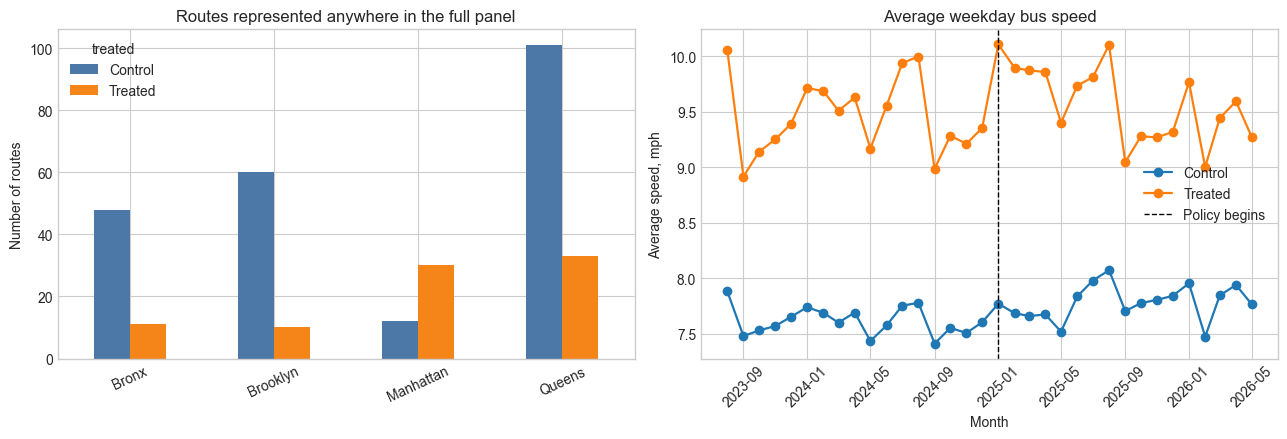

,treated,post_int,mean_speed,observations
0,Control,Pre,7.612,6570
1,Control,Post,7.783,6953
2,Treated,Pre,9.456,2835
3,Treated,Post,9.578,2750


In [3]:
route_borough = df[["route_id", "borough", "treated"]].drop_duplicates()
route_counts = (
    route_borough.groupby(["borough", "treated"])["route_id"]
    .nunique()
    .unstack(fill_value=0)
    .rename(columns={0: "Control", 1: "Treated"})
)

trend = (
    df.query("day_type == 1")
    .groupby(["month", "treated"], as_index=False)["average_speed"]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
route_counts.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Routes represented anywhere in the full panel")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of routes")
axes[0].tick_params(axis="x", rotation=25)

for treated_value, group in trend.groupby("treated"):
    label = "Treated" if treated_value else "Control"
    axes[1].plot(group["month"], group["average_speed"], marker="o", linewidth=1.6, label=label)
axes[1].axvline(POLICY_MONTH, color="black", linestyle="--", linewidth=1, label="Policy begins")
axes[1].set_title("Average weekday bus speed")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average speed, mph")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

prepost_means = (
    df.query("day_type == 1")
    .groupby(["treated", "post_int"], observed=True)["average_speed"]
    .agg(mean_speed="mean", observations="size")
    .reset_index()
    .replace({"treated": {0: "Control", 1: "Treated"}, "post_int": {0: "Pre", 1: "Post"}})
)
display(prepost_means.round(3))

Treated routes have higher average baseline speeds and are distributed differently across boroughs. Those level differences are absorbed by route fixed effects, but they motivate checking whether treated and control routes have adequate covariate overlap and comparable pre-policy changes.

## Assumption testing

The design relies on three main empirical conditions:

1. Treated and control routes have sufficient overlap in pre-policy characteristics.
2. Their untreated speed trends would have evolved in parallel.
3. Congestion pricing does not materially change the outcomes of comparison routes.

These diagnostics can reveal evidence against the assumptions, but they cannot prove that the assumptions hold.

### Overlap

The EDA above counts every route represented anywhere in the full panel (221 controls and 84 treated). The overlap model has a narrower eligibility requirement because its covariates must be measured before treatment on weekdays. Of the 221 control routes, 4 have no weekday observations and 25 first appear only after January 2025, leaving 192 controls eligible to receive a propensity score. A route-level logistic model predicts CBD exposure using borough, pre-policy weekday mean speed, speed variability, and speed trend. The common-support interval is the intersection of the treated and control propensity-score ranges; 10 eligible controls and 3 treated routes lie outside it. The final analysis sample therefore contains 182 controls and 81 treated routes. These are sequential sample restrictions, not contradictory counts.

,group,full_panel_routes,pre_weekday_eligible_routes,minimum_score,maximum_score,outside_common_support,retained_in_common_support
0,Control,221,192,0.008,0.995,10,182
1,Treated,84,84,0.020,0.998,3,81


Common support: [0.020, 0.995]
Analysis sample after trimming: 263 routes (81 treated, 182 control)


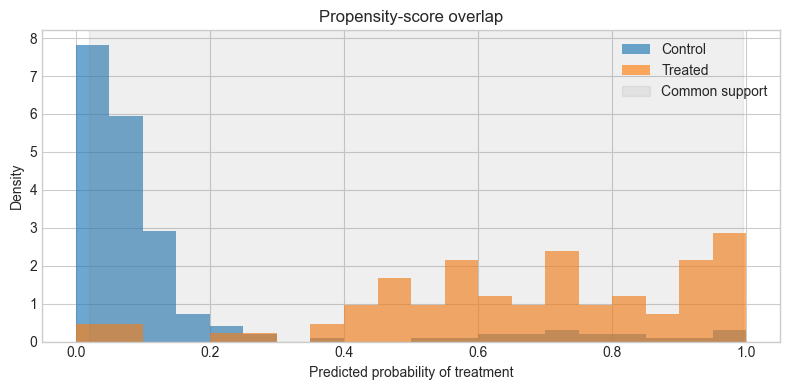

In [4]:
pre_weekday = df.query("day_type == 1 and month < @POLICY_MONTH").copy()
pre_route_month = (
    pre_weekday.groupby(["route_id", "month"], as_index=False)["average_speed"]
    .mean()
)
pre_slopes = (
    pre_route_month.sort_values(["route_id", "month"])
    .groupby("route_id")["average_speed"]
    .apply(lambda values: np.polyfit(np.arange(len(values)), values, 1)[0])
    .rename("pre_speed_slope")
)

route_overlap = (
    pre_weekday.groupby("route_id", as_index=False)
    .agg(
        treated=("treated", "first"),
        borough=("borough", "first"),
        pre_mean_speed=("average_speed", "mean"),
        pre_sd_speed=("average_speed", "std"),
    )
    .merge(pre_slopes, on="route_id", how="left")
)

continuous_predictors = ["pre_mean_speed", "pre_sd_speed", "pre_speed_slope"]
for column in continuous_predictors:
    route_overlap[f"z_{column}"] = (
        route_overlap[column] - route_overlap[column].mean()
    ) / route_overlap[column].std()

propensity_model = smf.glm(
    "treated ~ z_pre_mean_speed + z_pre_sd_speed + z_pre_speed_slope + C(borough)",
    data=route_overlap,
    family=sm.families.Binomial(),
).fit()
route_overlap["propensity_score"] = propensity_model.predict(route_overlap)

treated_scores = route_overlap.loc[route_overlap["treated"].eq(1), "propensity_score"]
control_scores = route_overlap.loc[route_overlap["treated"].eq(0), "propensity_score"]
support_low = max(treated_scores.min(), control_scores.min())
support_high = min(treated_scores.max(), control_scores.max())
route_overlap["in_common_support"] = route_overlap["propensity_score"].between(
    support_low, support_high
)

common_support_routes = set(
    route_overlap.loc[route_overlap["in_common_support"], "route_id"]
)
analysis_all = df.loc[df["route_id"].isin(common_support_routes)].copy()
analysis_weekday = analysis_all.query("day_type == 1").copy()
outside_support = route_overlap.loc[~route_overlap["in_common_support"]].copy()

overlap_summary = pd.DataFrame({
    "group": ["Control", "Treated"],
    "full_panel_routes": [
        df.loc[df["treated"].eq(0), "route_id"].nunique(),
        df.loc[df["treated"].eq(1), "route_id"].nunique(),
    ],
    "pre_weekday_eligible_routes": [len(control_scores), len(treated_scores)],
    "minimum_score": [control_scores.min(), treated_scores.min()],
    "maximum_score": [control_scores.max(), treated_scores.max()],
    "outside_common_support": [
        int((outside_support["treated"] == 0).sum()),
        int((outside_support["treated"] == 1).sum()),
    ],
    "retained_in_common_support": [
        int((route_overlap["in_common_support"] & route_overlap["treated"].eq(0)).sum()),
        int((route_overlap["in_common_support"] & route_overlap["treated"].eq(1)).sum()),
    ],
})

display(overlap_summary.round(3))
print(f"Common support: [{support_low:.3f}, {support_high:.3f}]")
print(
    f"Analysis sample after trimming: {analysis_weekday['route_id'].nunique():,} routes "
    f"({analysis_weekday.loc[analysis_weekday['treated'].eq(1), 'route_id'].nunique():,} treated, "
    f"{analysis_weekday.loc[analysis_weekday['treated'].eq(0), 'route_id'].nunique():,} control)"
)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 21)
ax.hist(control_scores, bins=bins, alpha=0.65, density=True, label="Control")
ax.hist(treated_scores, bins=bins, alpha=0.65, density=True, label="Treated")
ax.axvspan(support_low, support_high, color="grey", alpha=0.12, label="Common support")
ax.set_title("Propensity-score overlap")
ax.set_xlabel("Predicted probability of treatment")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
plt.show()

### Parallel trends

Parallel trends are assessed on the same common-support weekday sample used for the DiD. The event-study coefficients compare treated and control routes in each pre-policy month relative to December 2024. A joint test evaluates whether all lead coefficients are zero, while a linear interaction summarizes the average differential monthly trend.

,diagnostic,estimate,std_error,p_value,ci_low,ci_high
0,Joint event-study leads,NaN,NaN,0.0000,NaN,NaN
1,Linear differential trend (mph/month),0.0034,0.002,0.0944,-0.0006,0.0074


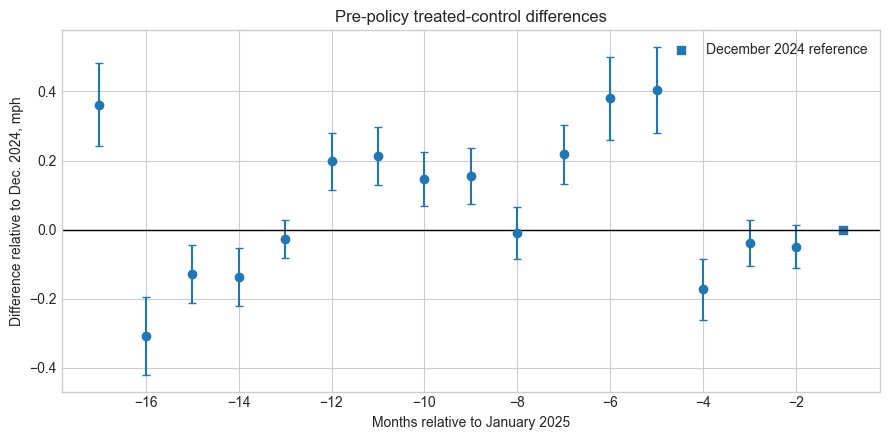

The joint test rejects zero pre-policy lead coefficients.


In [5]:
pt = analysis_weekday.copy()
pt["rel_month"] = (
    (pt["month"].dt.year - POLICY_MONTH.year) * 12
    + (pt["month"].dt.month - POLICY_MONTH.month)
).astype(int)
pre_pt = pt.loc[pt["rel_month"].between(-17, -1)].copy()
reference_month = -1
lead_months = [month for month in sorted(pre_pt["rel_month"].unique()) if month != reference_month]
lead_columns = []

for month in lead_months:
    column = f"treated_rel_{abs(month)}"
    pre_pt[column] = (
        pre_pt["treated"].eq(1) & pre_pt["rel_month"].eq(month)
    ).astype(int)
    lead_columns.append(column)

lead_model = smf.ols(
    "average_speed ~ " + " + ".join(lead_columns)
    + " + C(route_id) + C(month_str) + C(period)",
    data=pre_pt,
).fit(cov_type="cluster", cov_kwds={"groups": pre_pt["route_id"]})

lead_results = pd.DataFrame([
    {
        "rel_month": month,
        "estimate_mph": lead_model.params[column],
        "ci_low": lead_model.conf_int().loc[column, 0],
        "ci_high": lead_model.conf_int().loc[column, 1],
    }
    for month, column in zip(lead_months, lead_columns)
])
joint_test = lead_model.f_test(
    ", ".join(f"{column} = 0" for column in lead_columns)
)
joint_p_value = float(np.asarray(joint_test.pvalue).squeeze())

linear_pre = pre_pt.copy()
linear_pre["treated_time"] = linear_pre["treated"] * linear_pre["rel_month"]
linear_model = smf.ols(
    "average_speed ~ treated_time + C(route_id) + C(month_str) + C(period)",
    data=linear_pre,
).fit(cov_type="cluster", cov_kwds={"groups": linear_pre["route_id"]})
linear_ci = linear_model.conf_int().loc["treated_time"]

parallel_trends_summary = pd.DataFrame([
    {
        "diagnostic": "Joint event-study leads",
        "estimate": np.nan,
        "std_error": np.nan,
        "p_value": joint_p_value,
        "ci_low": np.nan,
        "ci_high": np.nan,
    },
    {
        "diagnostic": "Linear differential trend (mph/month)",
        "estimate": linear_model.params["treated_time"],
        "std_error": linear_model.bse["treated_time"],
        "p_value": linear_model.pvalues["treated_time"],
        "ci_low": linear_ci.iloc[0],
        "ci_high": linear_ci.iloc[1],
    },
])
display(parallel_trends_summary.round(4))

plot_leads = pd.concat([
    lead_results,
    pd.DataFrame([{"rel_month": -1, "estimate_mph": 0.0, "ci_low": 0.0, "ci_high": 0.0}]),
]).sort_values("rel_month")
non_reference = plot_leads["rel_month"] != -1

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(
    plot_leads.loc[non_reference, "rel_month"],
    plot_leads.loc[non_reference, "estimate_mph"],
    yerr=[
        plot_leads.loc[non_reference, "estimate_mph"] - plot_leads.loc[non_reference, "ci_low"],
        plot_leads.loc[non_reference, "ci_high"] - plot_leads.loc[non_reference, "estimate_mph"],
    ],
    fmt="o",
    capsize=3,
)
ax.scatter([-1], [0], marker="s", label="December 2024 reference")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Pre-policy treated-control differences")
ax.set_xlabel("Months relative to January 2025")
ax.set_ylabel("Difference relative to Dec. 2024, mph")
ax.legend()
fig.tight_layout()
plt.show()

if joint_p_value < 0.05:
    print("The joint test rejects zero pre-policy lead coefficients.")
else:
    print("The joint test does not reject zero pre-policy lead coefficients.")

In the common-support sample, the linear differential trend is **+0.0034 mph per month** (p = 0.094), so it is not statistically distinguishable from zero at the 5% level. However, the joint event-study test strongly rejects zero pre-policy lead coefficients (p < 0.001). The month-specific pre-policy differences therefore remain a meaningful concern even though there is no clear constant linear divergence.

### No interference

The working assumption is that any effect on comparison routes is small relative to the direct effect on treated routes. Travelers may change mode, departure time, or trip frequency rather than simply rerouting around the zone.

To assess local spillovers without imposing a distance cutoff, the test uses all common-support control routes with policy-date geometry. It estimates whether their post-policy speed changes vary with minimum distance from the congestion zone. A zero distance-by-post coefficient is consistent with negligible local interference. A uniform citywide spillover cannot be detected because month fixed effects absorb shocks shared by every control route.

,term,estimate_mph_per_km,std_error,p_value,ci_low,ci_high
0,Distance to CBD (km) ? post,0.0007,0.0037,0.8598,-0.0066,0.0079


Control routes included: 182; without policy-date geometry: 0


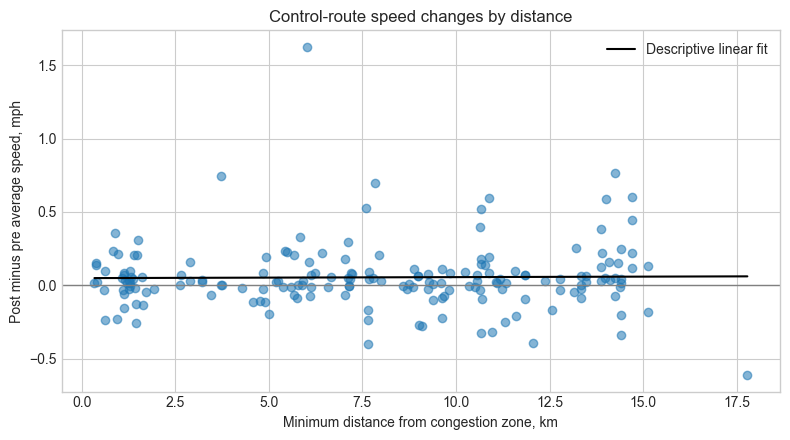

In [6]:
ACTIVE_SHAPES_WHERE = (
    "valid_from <= '2025-01-05' "
    "AND (valid_to IS NULL OR valid_to >= '2025-01-05')"
)
geofence = pd.read_csv(GEOFENCE_PATH)
cbd_wgs84 = gpd.GeoSeries(
    [unary_union([wkt.loads(value) for value in geofence["polygon"].dropna()])],
    crs="EPSG:4326",
)
cbd_2263 = cbd_wgs84.to_crs("EPSG:2263")

# GeoJSON lacks an index, so this policy-date filter still requires a sequential scan.
active_shapes = gpd.read_file(
    ROUTES_PATH,
    engine="pyogrio",
    columns=["route_id", "valid_from", "valid_to"],
    where=ACTIVE_SHAPES_WHERE,
)
active_shapes["route_id"] = active_shapes["route_id"].astype("string").str.strip().str.upper()
active_shapes = active_shapes.to_crs("EPSG:2263")
active_shapes["distance_to_cbd_km"] = (
    active_shapes.geometry.distance(cbd_2263.iloc[0]) * 0.3048 / 1_000
)

analysis_control_ids = set(
    route_overlap.loc[
        route_overlap["in_common_support"] & route_overlap["treated"].eq(0),
        "route_id",
    ]
)
control_distances = (
    active_shapes.loc[active_shapes["route_id"].isin(analysis_control_ids)]
    .groupby("route_id", as_index=False)["distance_to_cbd_km"]
    .min()
)
spillover_sample = (
    analysis_weekday.query("treated == 0")
    .merge(control_distances, on="route_id", how="inner")
    .copy()
)
spillover_sample["distance_post"] = (
    spillover_sample["distance_to_cbd_km"] * spillover_sample["post_int"]
)

spillover_model = smf.ols(
    "average_speed ~ distance_post + C(route_id) + C(month_str) + C(period)",
    data=spillover_sample,
).fit(cov_type="cluster", cov_kwds={"groups": spillover_sample["route_id"]})
spillover_ci = spillover_model.conf_int().loc["distance_post"]
spillover_result = pd.DataFrame([{
    "term": "Distance to CBD (km) ? post",
    "estimate_mph_per_km": spillover_model.params["distance_post"],
    "std_error": spillover_model.bse["distance_post"],
    "p_value": spillover_model.pvalues["distance_post"],
    "ci_low": spillover_ci.iloc[0],
    "ci_high": spillover_ci.iloc[1],
}])
display(spillover_result.round(4))
print(
    f"Control routes included: {control_distances['route_id'].nunique():,}; "
    f"without policy-date geometry: {len(analysis_control_ids) - control_distances['route_id'].nunique():,}"
)

control_change = (
    spillover_sample.groupby(["route_id", "distance_to_cbd_km", "post_int"])["average_speed"]
    .mean()
    .unstack("post_int")
    .dropna()
    .rename(columns={0: "pre_speed", 1: "post_speed"})
    .reset_index()
)
control_change["speed_change"] = control_change["post_speed"] - control_change["pre_speed"]
line_x = np.linspace(control_change["distance_to_cbd_km"].min(), control_change["distance_to_cbd_km"].max(), 100)
line_fit = np.polyfit(control_change["distance_to_cbd_km"], control_change["speed_change"], 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(control_change["distance_to_cbd_km"], control_change["speed_change"], alpha=0.55)
ax.plot(line_x, np.polyval(line_fit, line_x), color="black", linewidth=1.5, label="Descriptive linear fit")
ax.axhline(0, color="grey", linewidth=1)
ax.set_title("Control-route speed changes by distance")
ax.set_xlabel("Minimum distance from congestion zone, km")
ax.set_ylabel("Post minus pre average speed, mph")
ax.legend()
fig.tight_layout()
plt.show()

The estimated distance gradient is **+0.0007 mph per km**, with a 95% confidence interval of **[-0.0066, 0.0079]**. This is close to zero and provides no evidence that control-route changes vary systematically with proximity to the congestion zone. It does not rule out spillovers that affect all control routes similarly.

### System-wide spillovers

We aggregate the 182 common-support control routes into a weekday monthly network-speed series and compare it with a synthetic control formed from the same 35 non-NYC NTD donor agencies used in the synthetic-control robustness notebook. Both the NYC and donor series are centered on their own pre-policy means, and donor weights are nonnegative and sum to one.

A positive post-policy gap would be consistent with a shared improvement among NYC control routes that the within-NYC DiD cannot detect.

,comparison,control_routes,donor_pool_size,pre_rmspe,post_mean_gap_mph,post_mean_control_change_mph,post_mean_synthetic_change_mph
0,NYC common-support control-route network vs sy...,182,35,0.0787,0.1221,0.0369,-0.0852


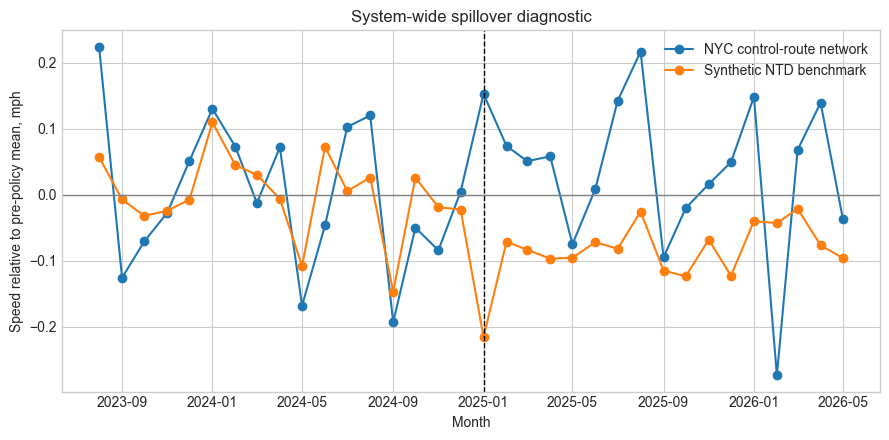

In [7]:
control_network_rows = analysis_weekday.query("treated == 0").copy()
for column in ["total_mileage", "total_operating_time"]:
    control_network_rows[column] = pd.to_numeric(
        control_network_rows[column].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )

control_network = (
    control_network_rows.groupby("month", as_index=False)
    .agg(
        total_mileage=("total_mileage", "sum"),
        total_operating_time=("total_operating_time", "sum"),
        route_count=("route_id", "nunique"),
    )
)
control_network["average_speed"] = (
    control_network["total_mileage"] / control_network["total_operating_time"]
)
control_network["unit_id"] = "NYC_CONTROL_ROUTES"

ntd_monthly = pd.read_csv(NTD_PANEL_PATH, dtype={"ntd_id": "string"})
ntd_monthly["month"] = pd.to_datetime(ntd_monthly["month"])
ntd_monthly["ntd_id"] = ntd_monthly["ntd_id"].str.zfill(5)
donor_pool = pd.read_csv(NTD_DONOR_POOL_PATH, dtype={"ntd_id": "string"})
donor_ids = donor_pool["ntd_id"].str.zfill(5).tolist()

donor_panel = (
    ntd_monthly.loc[
        ntd_monthly["ntd_id"].isin(donor_ids),
        ["month", "ntd_id", "average_speed"],
    ]
    .rename(columns={"ntd_id": "unit_id"})
    .copy()
)
spillover_synth_panel = pd.concat(
    [control_network[["month", "unit_id", "average_speed"]], donor_panel],
    ignore_index=True,
)
pre_mask = spillover_synth_panel["month"].lt(POLICY_MONTH)
pre_means = spillover_synth_panel.loc[pre_mask].groupby("unit_id")["average_speed"].mean()
spillover_synth_panel["centered_speed"] = (
    spillover_synth_panel["average_speed"]
    - spillover_synth_panel["unit_id"].map(pre_means)
)
spillover_wide = (
    spillover_synth_panel.pivot(index="month", columns="unit_id", values="centered_speed")
    .sort_index()
)
spillover_pre = spillover_wide.index < POLICY_MONTH
y_control_pre = spillover_wide.loc[spillover_pre, "NYC_CONTROL_ROUTES"].to_numpy()
x_donors_pre = spillover_wide.loc[spillover_pre, donor_ids].to_numpy()

def spillover_objective(weights):
    residual = y_control_pre - x_donors_pre @ weights
    return float(np.mean(residual ** 2))

initial_weights = np.repeat(1 / len(donor_ids), len(donor_ids))
spillover_fit = minimize(
    spillover_objective,
    initial_weights,
    method="SLSQP",
    bounds=[(0, 1)] * len(donor_ids),
    constraints={"type": "eq", "fun": lambda weights: weights.sum() - 1},
)
if not spillover_fit.success:
    raise RuntimeError(f"Synthetic spillover optimization failed: {spillover_fit.message}")
spillover_weights = np.where(spillover_fit.x < 1e-10, 0, spillover_fit.x)
spillover_weights = spillover_weights / spillover_weights.sum()

spillover_monthly = pd.DataFrame({
    "month": spillover_wide.index,
    "control_centered_speed": spillover_wide["NYC_CONTROL_ROUTES"].to_numpy(),
    "synthetic_centered_speed": spillover_wide[donor_ids].to_numpy() @ spillover_weights,
})
spillover_monthly["gap_mph"] = (
    spillover_monthly["control_centered_speed"]
    - spillover_monthly["synthetic_centered_speed"]
)
spillover_monthly["post"] = spillover_monthly["month"].ge(POLICY_MONTH)

spillover_summary = pd.DataFrame([{
    "comparison": "NYC common-support control-route network vs synthetic NTD agencies",
    "control_routes": control_network_rows["route_id"].nunique(),
    "donor_pool_size": len(donor_ids),
    "pre_rmspe": np.sqrt(
        np.mean(spillover_monthly.loc[~spillover_monthly["post"], "gap_mph"] ** 2)
    ),
    "post_mean_gap_mph": spillover_monthly.loc[
        spillover_monthly["post"], "gap_mph"
    ].mean(),
    "post_mean_control_change_mph": spillover_monthly.loc[
        spillover_monthly["post"], "control_centered_speed"
    ].mean(),
    "post_mean_synthetic_change_mph": spillover_monthly.loc[
        spillover_monthly["post"], "synthetic_centered_speed"
    ].mean(),
}])
spillover_summary.to_csv(SYSTEMWIDE_SPILLOVER_SUMMARY, index=False)
spillover_monthly.to_csv(SYSTEMWIDE_SPILLOVER_MONTHLY, index=False)
display(spillover_summary.round(4))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    spillover_monthly["month"],
    spillover_monthly["control_centered_speed"],
    marker="o",
    label="NYC control-route network",
)
ax.plot(
    spillover_monthly["month"],
    spillover_monthly["synthetic_centered_speed"],
    marker="o",
    label="Synthetic NTD benchmark",
)
ax.axvline(POLICY_MONTH, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="grey", linewidth=1)
ax.set_title("System-wide spillover diagnostic")
ax.set_xlabel("Month")
ax.set_ylabel("Speed relative to pre-policy mean, mph")
ax.legend()
fig.tight_layout()
plt.show()

The NYC control-route network is **0.122 mph above its synthetic NTD benchmark on average after January 2025**, while the pre-period RMSPE is **0.079 mph**. The positive gap is consistent with a modest system-wide improvement, but its magnitude alone does not show whether it is unusually large relative to synthetic-control prediction error. We therefore evaluate it using in-space placebo inference below.

#### In-space placebo inference

For each NTD donor agency, we repeat the analysis while treating that agency as if it received the policy and constructing its synthetic control from the other 34 donors. The test statistic is the signed post-policy mean gap divided by the pre-policy RMSPE. This normalization accounts for differences in pre-policy fit. Following a rule selected before inspecting the placebo results, we retain placebo units with pre-period RMSPE no greater than five times NYC's pre-period RMSPE. The one-sided test asks whether NYC has an unusually large positive gap; the two-sided test uses the absolute normalized gap.

,observed_post_mean_gap_mph,observed_pre_rmspe,observed_normalized_signed_gap,rmspe_filter_multiple,eligible_placebos,excluded_placebos,one_sided_p_value,two_sided_p_value
0,0.1221,0.0787,1.5514,5,33,2,0.3529,0.6471


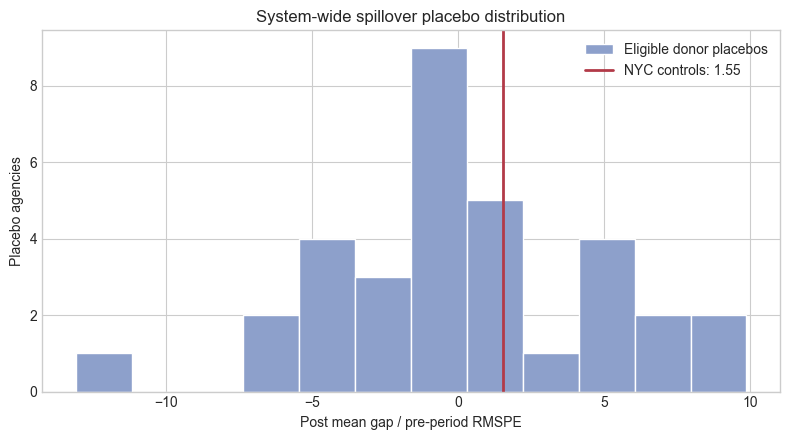

In [8]:
def fit_placebo_synthetic(treated_unit, comparison_units):
    y_pre = spillover_wide.loc[spillover_pre, treated_unit].to_numpy()
    x_pre = spillover_wide.loc[spillover_pre, comparison_units].to_numpy()

    def objective(weights):
        residual = y_pre - x_pre @ weights
        return float(np.mean(residual ** 2))

    initial = np.repeat(1 / len(comparison_units), len(comparison_units))
    fit = minimize(
        objective,
        initial,
        method="SLSQP",
        bounds=[(0, 1)] * len(comparison_units),
        constraints={"type": "eq", "fun": lambda weights: weights.sum() - 1},
    )
    if not fit.success:
        raise RuntimeError(f"Placebo optimization failed for {treated_unit}: {fit.message}")
    weights = np.where(fit.x < 1e-10, 0, fit.x)
    weights = weights / weights.sum()
    gap = (
        spillover_wide[treated_unit].to_numpy()
        - spillover_wide[comparison_units].to_numpy() @ weights
    )
    pre_rmspe = float(np.sqrt(np.mean(gap[spillover_pre] ** 2)))
    post_mean_gap = float(np.mean(gap[~spillover_pre]))
    return pre_rmspe, post_mean_gap

observed_pre_rmspe = float(spillover_summary.loc[0, "pre_rmspe"])
observed_post_gap = float(spillover_summary.loc[0, "post_mean_gap_mph"])
observed_statistic = observed_post_gap / observed_pre_rmspe

placebo_rows = []
for placebo_id in donor_ids:
    placebo_pre_rmspe, placebo_post_gap = fit_placebo_synthetic(
        placebo_id,
        [donor_id for donor_id in donor_ids if donor_id != placebo_id],
    )
    placebo_rows.append({
        "ntd_id": placebo_id,
        "pre_rmspe": placebo_pre_rmspe,
        "post_mean_gap_mph": placebo_post_gap,
        "normalized_signed_gap": placebo_post_gap / placebo_pre_rmspe,
        "normalized_absolute_gap": abs(placebo_post_gap) / placebo_pre_rmspe,
    })

placebo_results = pd.DataFrame(placebo_rows).merge(
    donor_pool[["ntd_id", "Agency"]].assign(
        ntd_id=lambda data: data["ntd_id"].str.zfill(5)
    ),
    on="ntd_id",
    how="left",
)
fit_threshold = 5 * observed_pre_rmspe
placebo_results["eligible_pre_fit"] = placebo_results["pre_rmspe"].le(fit_threshold)
eligible_placebos = placebo_results.loc[placebo_results["eligible_pre_fit"]].copy()

one_sided_p_value = (
    1 + eligible_placebos["normalized_signed_gap"].ge(observed_statistic).sum()
) / (1 + len(eligible_placebos))
two_sided_p_value = (
    1 + eligible_placebos["normalized_absolute_gap"].ge(abs(observed_statistic)).sum()
) / (1 + len(eligible_placebos))

placebo_test = pd.DataFrame([{
    "observed_post_mean_gap_mph": observed_post_gap,
    "observed_pre_rmspe": observed_pre_rmspe,
    "observed_normalized_signed_gap": observed_statistic,
    "rmspe_filter_multiple": 5,
    "eligible_placebos": len(eligible_placebos),
    "excluded_placebos": len(placebo_results) - len(eligible_placebos),
    "one_sided_p_value": one_sided_p_value,
    "two_sided_p_value": two_sided_p_value,
}])
placebo_results.to_csv(SYSTEMWIDE_SPILLOVER_PLACEBOS, index=False)
placebo_test.to_csv(SYSTEMWIDE_SPILLOVER_TEST, index=False)
display(placebo_test.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(
    eligible_placebos["normalized_signed_gap"],
    bins=12,
    color="#8DA0CB",
    edgecolor="white",
    label="Eligible donor placebos",
)
ax.axvline(
    observed_statistic,
    color="#B23A48",
    linewidth=2,
    label=f"NYC controls: {observed_statistic:.2f}",
)
ax.set_title("System-wide spillover placebo distribution")
ax.set_xlabel("Post mean gap / pre-period RMSPE")
ax.set_ylabel("Placebo agencies")
ax.legend()
fig.tight_layout()
plt.show()

NYC's normalized positive gap is **1.55**. Of the 35 donor placebos, 33 meet the pre-fit criterion. The one-sided placebo test gives (p=0.353), and the two-sided test gives (p=0.647). We therefore fail to reject the null that the apparent system-wide gap is no larger than the gaps generated by placebo assignments. Combined with the near-zero distance gradient, this provides no statistically conclusive evidence of interference. It does not prove that spillovers are absent: the placebo test has a small donor pool and relies on imperfectly comparable external agencies. The DiD should still be interpreted primarily as an incremental CBD-exposure effect, with common system-wide effects treated as an unresolved limitation.

## Difference-in-differences

The primary regression uses weekday observations from routes inside common propensity-score support:

`average_speed ~ treated ? post + route fixed effects + month fixed effects + period fixed effects`

Route fixed effects absorb permanent route differences, month fixed effects absorb citywide monthly shocks, and period fixed effects account for peak versus off-peak service. Standard errors are clustered by route. The coefficient on `treated ? post` is the relative post-policy change for treated routes.

In [9]:
def run_did(data, label):
    model = smf.ols(
        "average_speed ~ did + C(route_id) + C(month_str) + C(period)",
        data=data,
    ).fit(cov_type="cluster", cov_kwds={"groups": data["route_id"]})
    ci = model.conf_int().loc["did"]
    return model, {
        "sample": label,
        "rows": int(model.nobs),
        "routes": data["route_id"].nunique(),
        "treated_routes": data.loc[data["treated"].eq(1), "route_id"].nunique(),
        "control_routes": data.loc[data["treated"].eq(0), "route_id"].nunique(),
        "estimate_mph": model.params["did"],
        "std_error": model.bse["did"],
        "p_value": model.pvalues["did"],
        "ci_low": ci.iloc[0],
        "ci_high": ci.iloc[1],
    }

primary_model, primary_result = run_did(analysis_weekday, "Weekday, all periods")
_, all_days_result = run_did(analysis_all, "All day types")
_, peak_result = run_did(analysis_weekday.query("period == 'Peak'"), "Weekday peak")
_, offpeak_result = run_did(analysis_weekday.query("period == 'Off-Peak'"), "Weekday off-peak")

results = pd.DataFrame([
    primary_result,
    all_days_result,
    peak_result,
    offpeak_result,
])

## Results

The first row is the primary estimate. The remaining rows apply the same common-support route restriction to alternative day-type and service-period samples.

,sample,rows,routes,treated_routes,control_routes,estimate_mph,std_error,p_value,ci_low,ci_high
0,"Weekday, all periods",17815,263,81,182,0.1414,0.0477,0.0030,0.0479,0.2349
1,All day types,33827,263,81,182,0.1319,0.0443,0.0029,0.0451,0.2187
2,Weekday peak,8867,263,81,182,0.1623,0.0454,0.0004,0.0733,0.2514
3,Weekday off-peak,8948,263,81,182,0.1197,0.0544,0.0278,0.0130,0.2263


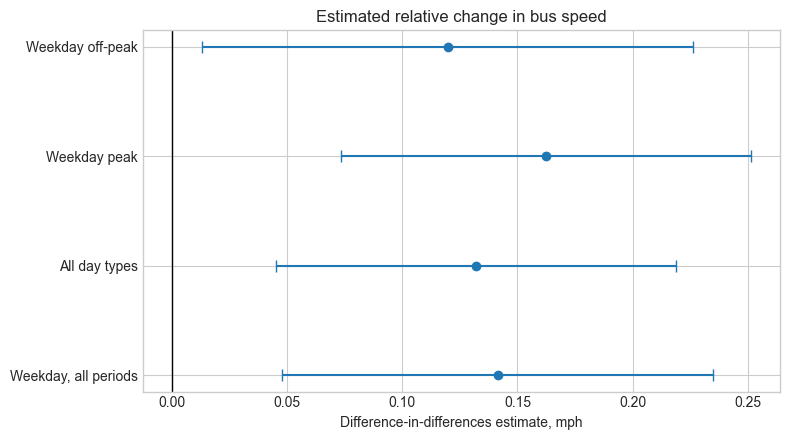

Primary estimate: +0.1414 mph (SE 0.0477, p=0.003022, 95% CI [0.0479, 0.2349]).


In [10]:
display(results.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_results = results.set_index("sample")
ax.errorbar(
    plot_results["estimate_mph"],
    plot_results.index,
    xerr=[
        plot_results["estimate_mph"] - plot_results["ci_low"],
        plot_results["ci_high"] - plot_results["estimate_mph"],
    ],
    fmt="o",
    capsize=4,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Estimated relative change in bus speed")
ax.set_xlabel("Difference-in-differences estimate, mph")
fig.tight_layout()
plt.show()

primary = results.iloc[0]
print(
    f"Primary estimate: {primary['estimate_mph']:+.4f} mph "
    f"(SE {primary['std_error']:.4f}, p={primary['p_value']:.4g}, "
    f"95% CI [{primary['ci_low']:.4f}, {primary['ci_high']:.4f}])."
)

Within common propensity-score support, the primary weekday estimate is **+0.1414 mph** (SE 0.0477, p = 0.003; 95% CI [0.0479, 0.2349]). The estimates remain positive for all day types, peak service, and off-peak service.

The result describes a modest relative increase in bus speed for treated routes after January 2025. Overlap is adequate after trimming, and the distance diagnostic finds no evidence of a local spillover gradient. However, the joint pre-policy event-study test raises a substantial parallel-trends concern. The estimate should therefore be reported as evidence of a positive relative change, with causal interpretation remaining cautious.